# The simplest RL problem: the 2-armed bandit.
this code and explanation are written by hand :)

---
The simplest RL problem is the two-armed bandit: 

**The 'Bandit' is a machine with 2 levers, A and B, each of which has a hidden probability distribution determining the reward returned when the lever is pulled. The 'Agent' attempts to maximize the cumulative reward received from the bandit using an epsilon-greedy approach.**

### setting up the bandit
Here I implement the two armed bandit as two normal distributions with different expected values (mu) and variances (sigma).

In [1]:
import numpy as np 
import random

In [2]:
class Bandit: 
    def __init__(self, muA, muB, sigA, sigB):
        self.muA = muA
        self.muB = muB
        self.sigA = sigA
        self.sigB = sigB

    def leverA(self):
        return np.random.normal(self.muA, self.sigA)
    
    def leverB(self):
        return np.random.normal(self.muB, self.sigB)

### setting up the agent
to 'solve' this bandit problem, the epsilon-greedy agent will simply estimate the expected values for each lever (a running average)
and pick the 'greedy' lever most of the time, or pick a random lever with probability epsilon. 

In [3]:
class EpsilonGreedyAgent: 

    def __init__(self, epsilon, bandit):
        self.bandit = bandit
        self.epsilon = epsilon
        self.total = 0
        self.estA = 0 
        self.estB = 0
        self.triesA = 0 
        self.triesB = 0

    def pickA(self):
        val = bandit.leverA()
        self.triesA += 1
        self.estA = self.estA * ((self.triesA - 1) / self.triesA) + val / self.triesA
        self.total += val

    def pickB(self):
        val = bandit.leverB()
        self.triesB += 1
        self.estB = self.estB * ((self.triesB - 1) / self.triesB) + val / self.triesB
        self.total += val

    def pick_lever(self): 
        pick = random.uniform(0, 1) 
        
        # greedy pick
        if pick > self.epsilon: 
            if self.estA > self.estB: 
                self.pickA()
            else:
                self.pickB()
                
        # random pick       
        else: 
            randn = random.uniform(0, 1)
            if randn > 0.5: 
                self.pickA()
            else:
                self.pickB()

### Experiments
With the bandit and the agent in place, we can play around with the agent to see how epsilon affects average reward over time.

In [4]:
def bandit_experiment(num_tries, epsilon, bandit):
    agent = EpsilonGreedyAgent(epsilon, bandit)
    for i in range(num_tries): 
        agent.pick_lever()
    return agent.total / num_tries, agent.estA, agent.estB

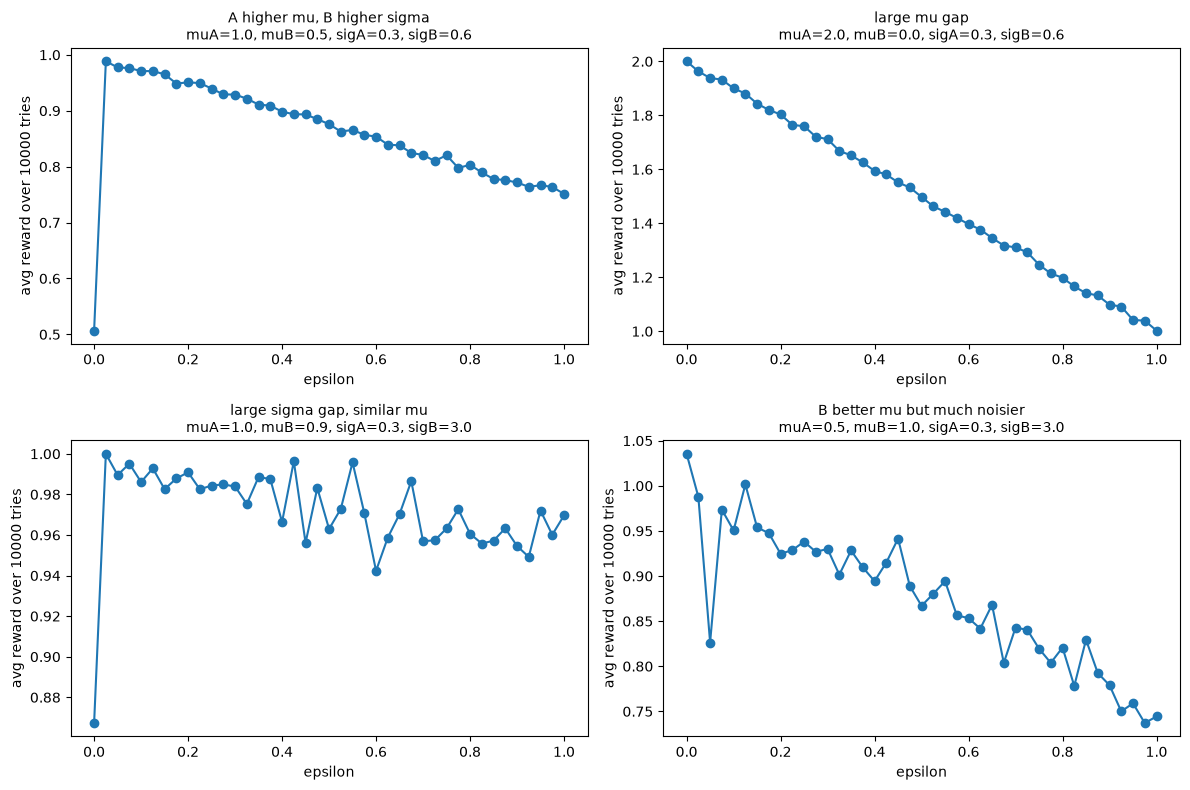

In [6]:
import matplotlib.pyplot as plt

scenarios = [
    (1.0, 0.5, 0.3, 0.6, 'A higher mu, B higher sigma'),
    (2.0, 0.0, 0.3, 0.6, 'large mu gap'),
    (1.0, 0.9, 0.3, 3.0, 'large sigma gap, similar mu'),
    (0.5, 1.0, 0.3, 3.0, 'B better mu but much noisier'),
]

num_tries = 10000
epsilons = np.linspace(0, 1, 41)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (muA, muB, sigA, sigB, desc) in zip(axes.flat, scenarios):
    bandit = Bandit(muA, muB, sigA, sigB)
    avg_rewards = [bandit_experiment(num_tries, eps, bandit)[0] for eps in epsilons]
    ax.plot(epsilons, avg_rewards, marker='o')
    ax.set_title(f'{desc}\nmuA={muA}, muB={muB}, sigA={sigA}, sigB={sigB}', fontsize=10)
    ax.set_xlabel('epsilon')
    ax.set_ylabel(f'avg reward over {num_tries} tries')
    
plt.tight_layout()
plt.show()


### Results: the greedier the better (mostly) 
since the bandit is so simple, the agent is likely to get good enough estimates of the expected values for each lever after very little 
exploration. Thus, greedier agents work better, as long as they explore a little bit. notice how greedy agents (eps=0) may do terribly when the difference in mu is small and the weaker lever has a higher variance. also notice how larger variances cause the results to be noisier. 

***challenge question***: the 'large sigma gap, similar mu' experiment shows more randomness in average reward around the mid-range epsilons, whereas 'B better mu but much noisier' shows more randomness at epsilons closer to zero. why this difference?
